In [ ]:
import pandas as pd


# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Filtrar los clientes que suscribieron un depósito a término
clientes_con_deposito = df[df['y'] == 'yes']

# Calcular el monto promedio de balance
monto_promedio = clientes_con_deposito['balance'].mean()

# Tasa de interés efectiva anual (TEA) que paga el banco
TEA = 9.83 / 100  # Convertir a decimal

# Tasa de interés que cobra el banco
tasa_interes_banco = 15.75 / 100  # Convertir a decimal

# Calcular el beneficio del banco asociado a un verdadero positivo (TP)
P= monto_promedio * (tasa_interes_banco - TEA)

print(f'P: {P:.2f} euros')

salario_hora_pesos = 8304  # salario por hora en pesos colombianos
tasa_conversion = 4808.10  # tasa de conversión de pesos colombianos a euros
duration = df['duration'].mean() 

# Convertir salario a euros
salario_hora_euros = salario_hora_pesos / tasa_conversion

# Calcular costo por segundo
costo_por_segundo = salario_hora_euros / 3600

# Calcular el costo de un falso positivo
CC = costo_por_segundo * duration

print(f"CC: {CC:.2f} euros")



P: 106.81 euros
CC: 0.12 euros


y
1    20726
0    14358
Name: count, dtype: int64
Epoch 1/50
1097/1097 [==============================] - 14s 8ms/step - loss: 0.6760 - accuracy: 0.6681 - val_loss: 1.4359 - val_accuracy: 0.3408
Epoch 2/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5322 - accuracy: 0.6965 - val_loss: 1.3162 - val_accuracy: 0.4039
Epoch 3/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5103 - accuracy: 0.7062 - val_loss: 1.3319 - val_accuracy: 0.3542
Epoch 4/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4984 - accuracy: 0.7117 - val_loss: 1.3629 - val_accuracy: 0.3873
Epoch 5/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4905 - accuracy: 0.7186 - val_loss: 1.1546 - val_accuracy: 0.4533
Epoch 6/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4880 - accuracy: 0.7209 - val_loss: 1.2238 - val_accuracy: 0.4057
Epoch 7/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4847 - 

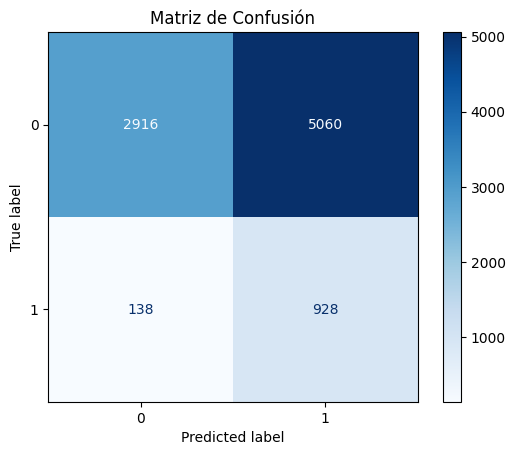

              precision    recall  f1-score   support

           0       0.95      0.37      0.53      7976
           1       0.15      0.87      0.26      1066

    accuracy                           0.43      9042
   macro avg       0.55      0.62      0.40      9042
weighted avg       0.86      0.43      0.50      9042

Verdaderos Negativos (TN): 2916
Falsos Positivos (FP): 5060
Falsos Negativos (FN): 138
Verdaderos Positivos (TP): 928
Ingresos esperados (I): 84001.53 euros


In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20665
0    14399
Name: count, dtype: int64
Epoch 1/50
1096/1096 [==============================] - 4s 2ms/step - loss: 0.6194 - accuracy: 0.6525 - val_loss: 1.2037 - val_accuracy: 0.4244
Epoch 2/50
1096/1096 [==============================] - 3s 2ms/step - loss: 0.5340 - accuracy: 0.6894 - val_loss: 1.2210 - val_accuracy: 0.4324
Epoch 3/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5136 - accuracy: 0.7041 - val_loss: 1.1570 - val_accuracy: 0.4531
Epoch 4/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5044 - accuracy: 0.7051 - val_loss: 1.1455 - val_accuracy: 0.4576
Epoch 5/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4954 - accuracy: 0.7165 - val_loss: 1.2378 - val_accuracy: 0.4370
Epoch 6/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4900 - accuracy: 0.7208 - val_loss: 1.1946 - val_accuracy: 0.4182
Epoch 7/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4915 - a

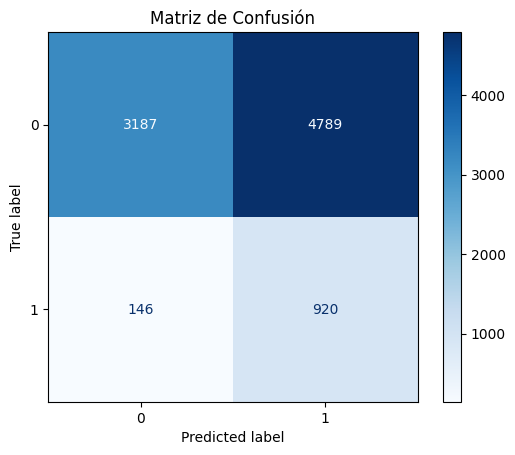

              precision    recall  f1-score   support

           0       0.96      0.40      0.56      7976
           1       0.16      0.86      0.27      1066

    accuracy                           0.45      9042
   macro avg       0.56      0.63      0.42      9042
weighted avg       0.86      0.45      0.53      9042

Verdaderos Negativos (TN): 3187
Falsos Positivos (FP): 4789
Falsos Negativos (FN): 146
Verdaderos Positivos (TP): 920
Ingresos esperados (I): 82360.64 euros


In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan'], inplace=True)

# Convertir las categorías a valores numéricos
cat_int_feats = ['housing', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 5s 3ms/step - loss: 0.7602 - accuracy: 0.6539 - val_loss: 1.5659 - val_accuracy: 0.3088
Epoch 2/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5675 - accuracy: 0.6815 - val_loss: 1.5286 - val_accuracy: 0.2618
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5485 - accuracy: 0.6846 - val_loss: 1.5515 - val_accuracy: 0.3163
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5369 - accuracy: 0.6954 - val_loss: 1.3598 - val_accuracy: 0.3280
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5280 - accuracy: 0.6977 - val_loss: 1.2202 - val_accuracy: 0.4302
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5206 - accuracy: 0.7083 - val_loss: 1.2998 - val_accuracy: 0.3865
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5158 - a

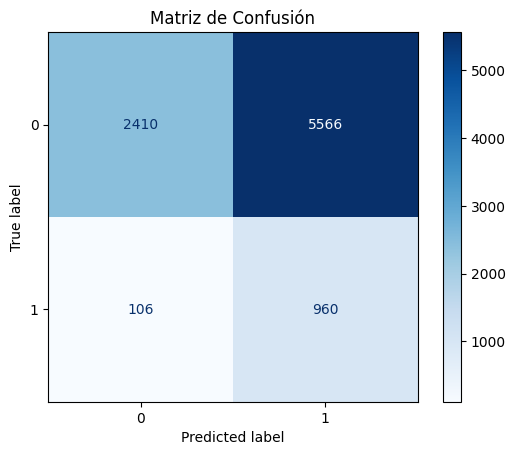

              precision    recall  f1-score   support

           0       0.96      0.30      0.46      7976
           1       0.15      0.90      0.25      1066

    accuracy                           0.37      9042
   macro avg       0.55      0.60      0.36      9042
weighted avg       0.86      0.37      0.44      9042

Verdaderos Negativos (TN): 2410
Falsos Positivos (FP): 5566
Falsos Negativos (FN): 106
Verdaderos Positivos (TP): 960
Ingresos esperados (I): 90708.23 euros


In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5042 - accuracy: 0.7536 - val_loss: 0.6270 - val_accuracy: 0.7057
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4258 - accuracy: 0.8051 - val_loss: 0.6264 - val_accuracy: 0.7092
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4067 - accuracy: 0.8154 - val_loss: 0.6340 - val_accuracy: 0.7130
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4002 - accuracy: 0.8210 - val_loss: 0.5541 - val_accuracy: 0.7497
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3938 - accuracy: 0.8243 - val_loss: 0.5891 - val_accuracy: 0.7299
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3886 - accuracy: 0.8288 - val_loss: 0.5788 - val_accuracy: 0.7242
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3878 - a

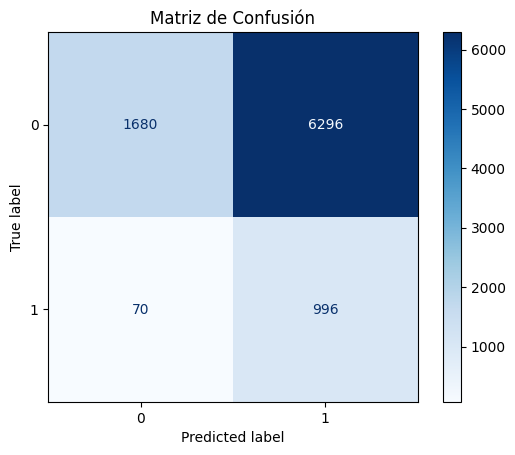

              precision    recall  f1-score   support

           0       0.96      0.21      0.35      7976
           1       0.14      0.93      0.24      1066

    accuracy                           0.30      9042
   macro avg       0.55      0.57      0.29      9042
weighted avg       0.86      0.30      0.33      9042

Verdaderos Negativos (TN): 1680
Falsos Positivos (FP): 6296
Falsos Negativos (FN): 70
Verdaderos Positivos (TP): 996
Ingresos esperados (I): 98213.46 euros


In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.1).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_01.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5055 - accuracy: 0.7532 - val_loss: 0.5688 - val_accuracy: 0.7430
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4267 - accuracy: 0.8029 - val_loss: 0.5944 - val_accuracy: 0.7322
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4101 - accuracy: 0.8159 - val_loss: 0.5808 - val_accuracy: 0.7394
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4006 - accuracy: 0.8186 - val_loss: 0.6102 - val_accuracy: 0.7062
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3934 - accuracy: 0.8262 - val_loss: 0.5534 - val_accuracy: 0.7454
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3889 - accuracy: 0.8256 - val_loss: 0.5409 - val_accuracy: 0.7614
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3861 - a

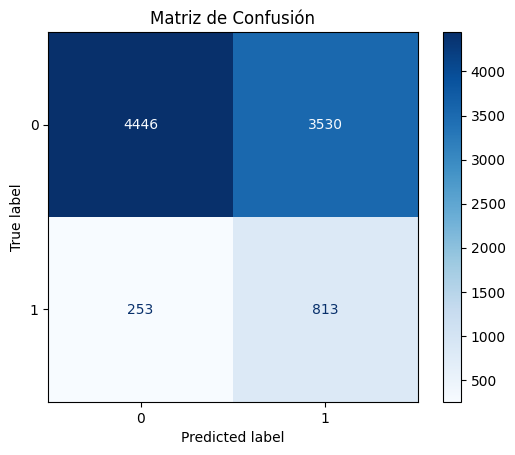

              precision    recall  f1-score   support

           0       0.95      0.56      0.70      7976
           1       0.19      0.76      0.30      1066

    accuracy                           0.58      9042
   macro avg       0.57      0.66      0.50      9042
weighted avg       0.86      0.58      0.65      9042

Verdaderos Negativos (TN): 4446
Falsos Positivos (FP): 3530
Falsos Negativos (FN): 253
Verdaderos Positivos (TP): 813
Ingresos esperados (I): 59827.85 euros


In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.2).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_02.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4993 - accuracy: 0.7527 - val_loss: 0.6220 - val_accuracy: 0.7092
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4237 - accuracy: 0.8044 - val_loss: 0.6124 - val_accuracy: 0.7332
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4097 - accuracy: 0.8134 - val_loss: 0.6003 - val_accuracy: 0.7378
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4004 - accuracy: 0.8201 - val_loss: 0.5431 - val_accuracy: 0.7806
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3970 - accuracy: 0.8213 - val_loss: 0.5489 - val_accuracy: 0.7712
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3912 - accuracy: 0.8245 - val_loss: 0.5659 - val_accuracy: 0.7408
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3855 - a

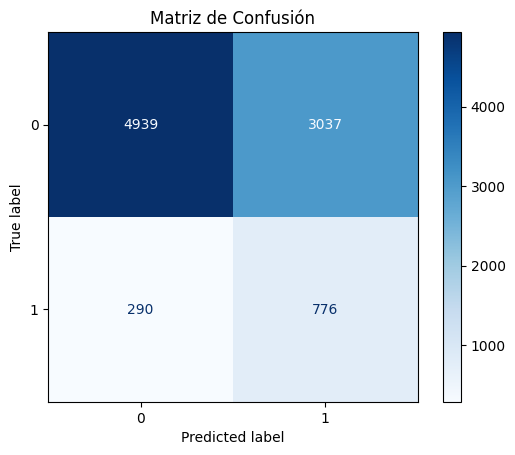

              precision    recall  f1-score   support

           0       0.94      0.62      0.75      7976
           1       0.20      0.73      0.32      1066

    accuracy                           0.63      9042
   macro avg       0.57      0.67      0.53      9042
weighted avg       0.86      0.63      0.70      9042

Verdaderos Negativos (TN): 4939
Falsos Positivos (FP): 3037
Falsos Negativos (FN): 290
Verdaderos Positivos (TP): 776
Ingresos esperados (I): 52050.41 euros


In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.3).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_03.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5054 - accuracy: 0.7538 - val_loss: 0.5755 - val_accuracy: 0.7238
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4242 - accuracy: 0.8060 - val_loss: 0.5303 - val_accuracy: 0.7626
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4101 - accuracy: 0.8138 - val_loss: 0.5351 - val_accuracy: 0.7628
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3983 - accuracy: 0.8231 - val_loss: 0.5437 - val_accuracy: 0.7673
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3943 - accuracy: 0.8247 - val_loss: 0.5593 - val_accuracy: 0.7494
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3921 - accuracy: 0.8257 - val_loss: 0.4971 - val_accuracy: 0.7899
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3853 - a

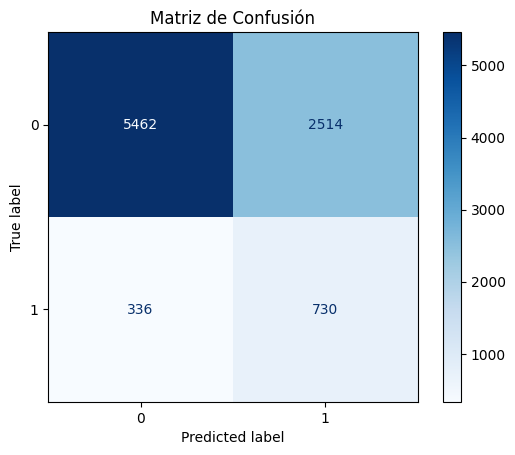

              precision    recall  f1-score   support

           0       0.94      0.68      0.79      7976
           1       0.23      0.68      0.34      1066

    accuracy                           0.68      9042
   macro avg       0.58      0.68      0.57      9042
weighted avg       0.86      0.68      0.74      9042

Verdaderos Negativos (TN): 5462
Falsos Positivos (FP): 2514
Falsos Negativos (FN): 336
Verdaderos Positivos (TP): 730
Ingresos esperados (I): 42358.89 euros


In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.4).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_04.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4996 - accuracy: 0.7558 - val_loss: 0.6011 - val_accuracy: 0.7045
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4215 - accuracy: 0.8070 - val_loss: 0.5884 - val_accuracy: 0.7212
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4078 - accuracy: 0.8158 - val_loss: 0.5666 - val_accuracy: 0.7405
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3976 - accuracy: 0.8215 - val_loss: 0.6059 - val_accuracy: 0.7172
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3915 - accuracy: 0.8264 - val_loss: 0.6150 - val_accuracy: 0.7234
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3886 - accuracy: 0.8275 - val_loss: 0.5853 - val_accuracy: 0.7559
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3857 - a

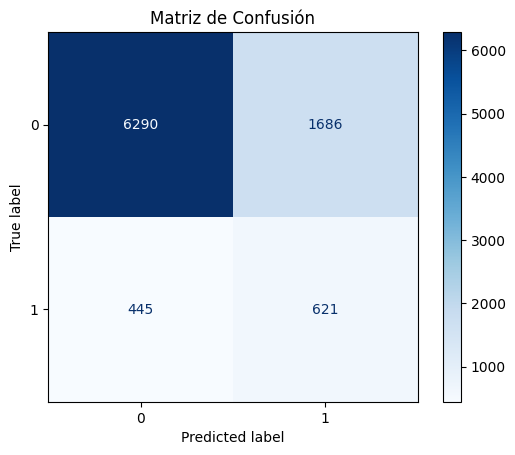

              precision    recall  f1-score   support

           0       0.93      0.79      0.86      7976
           1       0.27      0.58      0.37      1066

    accuracy                           0.76      9042
   macro avg       0.60      0.69      0.61      9042
weighted avg       0.86      0.76      0.80      9042

Verdaderos Negativos (TN): 6290
Falsos Positivos (FP): 1686
Falsos Negativos (FN): 445
Verdaderos Positivos (TP): 621
Ingresos esperados (I): 19292.33 euros


In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_05.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5053 - accuracy: 0.7529 - val_loss: 0.5702 - val_accuracy: 0.7380
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4237 - accuracy: 0.8058 - val_loss: 0.5964 - val_accuracy: 0.7311
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4078 - accuracy: 0.8164 - val_loss: 0.5468 - val_accuracy: 0.7673
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3964 - accuracy: 0.8226 - val_loss: 0.5975 - val_accuracy: 0.7385
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3923 - accuracy: 0.8260 - val_loss: 0.5515 - val_accuracy: 0.7524
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3902 - accuracy: 0.8276 - val_loss: 0.5889 - val_accuracy: 0.7280
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3865 - a

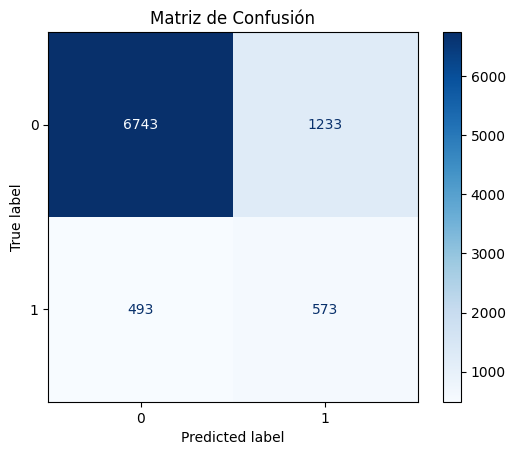

              precision    recall  f1-score   support

           0       0.93      0.85      0.89      7976
           1       0.32      0.54      0.40      1066

    accuracy                           0.81      9042
   macro avg       0.62      0.69      0.64      9042
weighted avg       0.86      0.81      0.83      9042

Verdaderos Negativos (TN): 6743
Falsos Positivos (FP): 1233
Falsos Negativos (FN): 493
Verdaderos Positivos (TP): 573
Ingresos esperados (I): 9156.47 euros


In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.6).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_06.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4986 - accuracy: 0.7544 - val_loss: 0.5501 - val_accuracy: 0.7403
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4254 - accuracy: 0.8067 - val_loss: 0.5501 - val_accuracy: 0.7513
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4085 - accuracy: 0.8146 - val_loss: 0.5671 - val_accuracy: 0.7430
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3984 - accuracy: 0.8208 - val_loss: 0.5738 - val_accuracy: 0.7530
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3948 - accuracy: 0.8245 - val_loss: 0.5783 - val_accuracy: 0.7329
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3865 - accuracy: 0.8295 - val_loss: 0.5771 - val_accuracy: 0.7451
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3866 - a

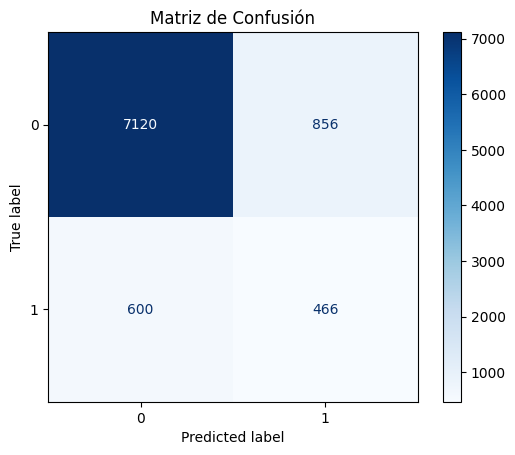

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      7976
           1       0.35      0.44      0.39      1066

    accuracy                           0.84      9042
   macro avg       0.64      0.66      0.65      9042
weighted avg       0.86      0.84      0.85      9042

Verdaderos Negativos (TN): 7120
Falsos Positivos (FP): 856
Falsos Negativos (FN): 600
Verdaderos Positivos (TP): 466
Ingresos esperados (I): -13594.80 euros


In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.7).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_07.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 4s 3ms/step - loss: 0.4994 - accuracy: 0.7537 - val_loss: 0.5804 - val_accuracy: 0.7282
Epoch 2/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4227 - accuracy: 0.8078 - val_loss: 0.5675 - val_accuracy: 0.7362
Epoch 3/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4064 - accuracy: 0.8152 - val_loss: 0.5794 - val_accuracy: 0.7299
Epoch 4/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3986 - accuracy: 0.8203 - val_loss: 0.6069 - val_accuracy: 0.7346
Epoch 5/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3945 - accuracy: 0.8253 - val_loss: 0.6151 - val_accuracy: 0.7141
Epoch 6/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3884 - accuracy: 0.8278 - val_loss: 0.6077 - val_accuracy: 0.7162
Epoch 7/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3858 - a

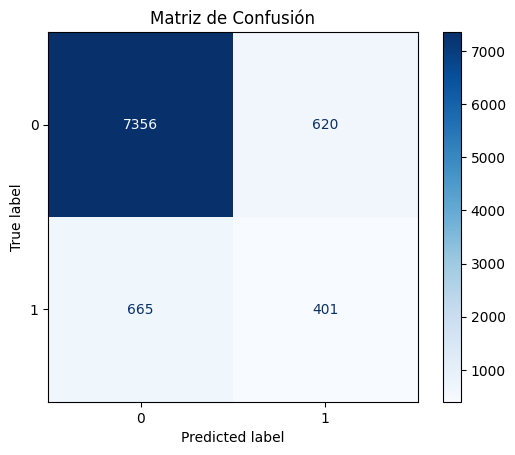

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7976
           1       0.39      0.38      0.38      1066

    accuracy                           0.86      9042
   macro avg       0.65      0.65      0.65      9042
weighted avg       0.86      0.86      0.86      9042

Verdaderos Negativos (TN): 7356
Falsos Positivos (FP): 620
Falsos Negativos (FN): 665
Verdaderos Positivos (TP): 401
Ingresos esperados (I): -27413.94 euros


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.8).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_08.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 4s 3ms/step - loss: 0.4953 - accuracy: 0.7605 - val_loss: 0.5551 - val_accuracy: 0.7126
Epoch 2/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4212 - accuracy: 0.8087 - val_loss: 0.5747 - val_accuracy: 0.7249
Epoch 3/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4075 - accuracy: 0.8169 - val_loss: 0.5581 - val_accuracy: 0.7317
Epoch 4/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3998 - accuracy: 0.8211 - val_loss: 0.5326 - val_accuracy: 0.7647
Epoch 5/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3945 - accuracy: 0.8235 - val_loss: 0.5356 - val_accuracy: 0.7520
Epoch 6/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3905 - accuracy: 0.8272 - val_loss: 0.5792 - val_accuracy: 0.7342
Epoch 7/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.3855 - a

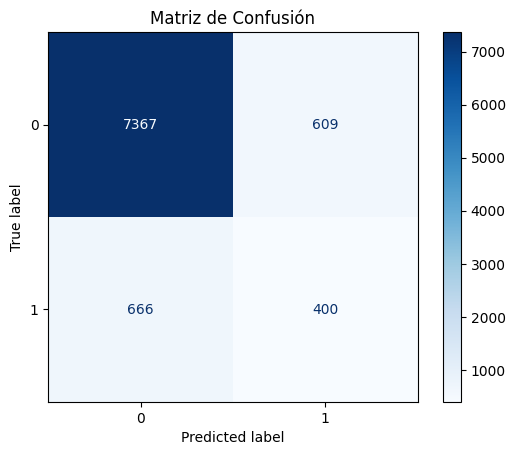

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7976
           1       0.40      0.38      0.39      1066

    accuracy                           0.86      9042
   macro avg       0.66      0.65      0.65      9042
weighted avg       0.86      0.86      0.86      9042

Verdaderos Negativos (TN): 7367
Falsos Positivos (FP): 609
Falsos Negativos (FN): 666
Verdaderos Positivos (TP): 400
Ingresos esperados (I): -27624.71 euros


In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.8).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_09.keras')

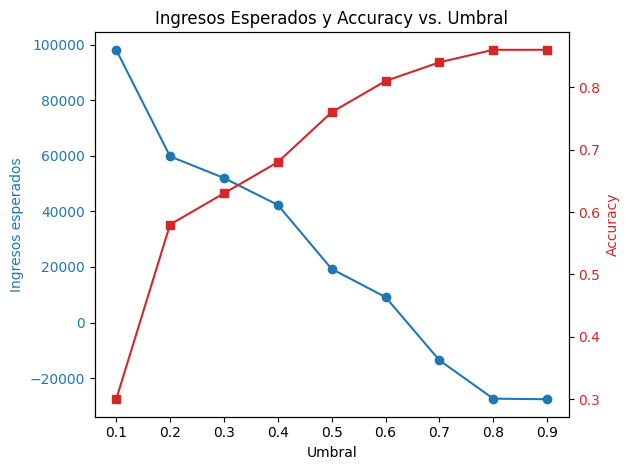

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV
data = pd.read_csv('Umbral.csv')

# Crear la figura y los ejes
fig, ax1 = plt.subplots()

# Crear el gráfico para los Ingresos Esperados
color = 'tab:blue'
ax1.set_xlabel('Umbral')
ax1.set_ylabel('Ingresos esperados', color=color)
ax1.plot(data['Umbral'], data['Ingresos esperados'], color=color, marker='o', label='Ingresos esperados')
ax1.tick_params(axis='y', labelcolor=color)

# Crear un segundo eje para la precisión
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Accuracy', color=color)  
ax2.plot(data['Umbral'], data['Accuracy'], color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Añadir título y leyenda
plt.title('Ingresos Esperados y Accuracy vs. Umbral')
fig.tight_layout()  
plt.show()
